## EJERCICIO 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv

class SOM:
    def __init__(self, filas, columnas, dim_entrada, tasa_aprendizaje=0.5, radio_vecindad=None):
        self.filas = filas
        self.columnas = columnas
        self.dim_entrada = dim_entrada
        
        np.random.seed(42)
        self.pesos = np.random.uniform(-0.5, 0.5, (filas, columnas, dim_entrada))
        
        self.ta_inicial = tasa_aprendizaje
        # El radio es la cantidad de casilleros alrededor de la ganadora
        if radio_vecindad is None:
            self.radio_inicial = max(filas, columnas) // 2
        else:
            self.radio_inicial = int(radio_vecindad)

    def encontrar_bmu(self, x):
        """Encuentra la neurona ganadora (distancia Euclidiana)"""
        distancias = np.linalg.norm(self.pesos - x, axis=2)
        bmu_idx = np.unravel_index(np.argmin(distancias, axis=None), distancias.shape)
        return bmu_idx

    def actualizar_pesos(self, x, f_bmu, c_bmu, radio, ta_actual):
        # Definimos los límites del cuadrado asegurando que no se salgan de la matriz
        f_min = max(0, f_bmu - radio)
        f_max = min(self.filas, f_bmu + radio + 1)
        c_min = max(0, c_bmu - radio)
        c_max = min(self.columnas, c_bmu + radio + 1)
        
        # W = W + ta_actual * (x - W) 
        self.pesos[f_min:f_max, c_min:c_max, :] += ta_actual * (x - self.pesos[f_min:f_max, c_min:c_max, :])

    def train(self, datos, epocas_ordenamiento=500, epocas_transicion=300, epocas_ajuste=200):
      
        # ETAPA 0: Ordenamiento Global (tasa aprendizaje alta)
        radio = self.radio_inicial
        ta_actual = self.ta_inicial
        
        for _ in range(epocas_ordenamiento):
            for x in datos:
                f_bmu, c_bmu = self.encontrar_bmu(x)
                self.actualizar_pesos(x, f_bmu, c_bmu, radio, ta_actual)
                

        # ETAPA 1: Transición (Decaimiento lineal)
        radio_final = 1
        ta_final = 0.1
        
        for epoca in range(epocas_transicion):
            np.random.shuffle(datos)
            
            # Cálculo de la pendiente lineal (y = mx + b)
            radio_actual = int(round(radio - ((radio - radio_final) / epocas_transicion) * epoca))
            ta_actual = ta_actual - ((ta_actual - ta_final) / epocas_transicion) * epoca
            
            for x in datos:
                f_bmu, c_bmu = self.encontrar_bmu(x)
                self.actualizar_pesos(x, f_bmu, c_bmu, radio_actual, ta_actual)
                

        # ETAPA 2: Ajusta la ganadora con una tasa baja
        radio_ajuste = 0 
        ta_ajuste = 0.01
        
        for _ in range(epocas_ajuste):
            np.random.shuffle(datos)
            for x in datos:
                f_bmu, c_bmu = self.encontrar_bmu(x)
                self.actualizar_pesos(x, f_bmu, c_bmu, radio_ajuste, ta_ajuste)


    def obtener_bmus(self, datos):
        """Devuelve las neuronas ganadoras"""
        bmus_1d = []
        bmus_2d = []
        for x in datos:
            f, c = self.encontrar_bmu(x)
            bmus_1d.append(f * self.columnas + c)
            bmus_2d.append((f, c))
        return np.array(bmus_1d), bmus_2d


    def graficar_clasificacion_2D(self, datos, dim_x=0, dim_y=1):
        """Graficador de dispersión genérico para cruzar 2 dimensiones"""
        colores = []
        for x in datos:
            f, c = self.encontrar_bmu(x)
            colores.append(f * self.columnas + c)
            
        plt.figure(figsize=(4, 4))
        plt.scatter(datos[:, dim_x], datos[:, dim_y], c=colores, cmap='tab20', s=15, alpha=0.6, label='Datos')
        
        centroides_x = self.pesos[:, :, dim_x].flatten()
        centroides_y = self.pesos[:, :, dim_y].flatten()
        
        plt.scatter(centroides_x, centroides_y, c='black', marker='X', s=100, label='Centroides', edgecolors='white')
        plt.title("Clasificación Final - SOM")
        plt.legend()
        plt.axis('equal')
        plt.show()

In [5]:
class KMedias:
    def __init__(self, X, k, max_iter=1000):
        self.X = np.asarray(X, dtype=float)
        self.k = int(k)
        self.max_iter = max_iter
        self.n, self.d = self.X.shape 
        self.rng = np.random.default_rng()
        self.labels = np.zeros(self.n, dtype=int)  # Array para guardar a que cluster 
               

        # PASO 1: Seleccionar aleatoriamente k centroides
        idx_aleatorios = self.rng.choice(self.n, size=self.k, replace=False) 
        self.centroides = self.X[idx_aleatorios].copy()
        
    def asignar(self):
        # PASO 2: Asignar los puntos al centroide más cercano
        nuevas = []
        for xi in self.X:
            # Distancia euclidiana al cuadrado
            distancias = np.sum((self.centroides - xi)**2, axis=1)
            nuevas.append(np.argmin(distancias))
        self.labels = np.array(nuevas, dtype=int)

    def recalcular_centroides(self):
        # PASO 3: Recalcular los centroides por grupo
        for j in range(self.k):
            puntos_j = self.X[self.labels == j]
            if len(puntos_j) == 0: 
                # Si se vacía --> lo movemos a un punto aleatorio
                self.centroides[j] = self.X[self.rng.choice(self.n)]
            else:
                self.centroides[j] = puntos_j.mean(axis=0)
                

    def train(self):
        # PASO 4: Repetimos 2 y 3 hasta que converja
        for _ in range(self.max_iter):
            labels_viejas = self.labels.copy()  # copia grupos
            
            self.asignar() # Paso 2
            
            # Si nadie cambio de grupo cornverge
            if np.array_equal(self.labels, labels_viejas): 
                break
                
            self.recalcular_centroides() # Paso 3
            
    def predict(self, Xn):
        Xn = np.asarray(Xn, dtype=float)
        out = []
        for x in Xn:
            distancias = np.sum((self.centroides - x)**2, axis=1)
            out.append(np.argmin(distancias))
        return np.array(out, dtype=int)

    def graficar_clasificacion_2D(self, datos, dim_x=0, dim_y=1):
        colores = self.predict(datos)
        
        plt.figure(figsize=(4, 4))
        plt.scatter(datos[:, dim_x], datos[:, dim_y], c=colores, cmap='tab20', s=15, alpha=0.6, label='Datos')
        
        centroides_x = self.centroides[:, dim_x]
        centroides_y = self.centroides[:, dim_y]
        
        plt.scatter(centroides_x, centroides_y, c='black', marker='X', s=100, label='Centroides', edgecolors='white')
        plt.title("Clasificación Final - K-Medias")
        plt.legend()
        plt.axis('equal')
        plt.show()


    @property
    def inercia(self):
        # El algoritmo minimiza la Suma de las distancias al cuadrado (SSE)
        suma = 0
        for i, x in enumerate(self.X):
            cluster = self.labels[i]
            suma += np.sum((x - self.centroides[cluster])**2)
        return suma



Entrenando K-Medias (K=3)...
Entrenando SOM (2x2)...


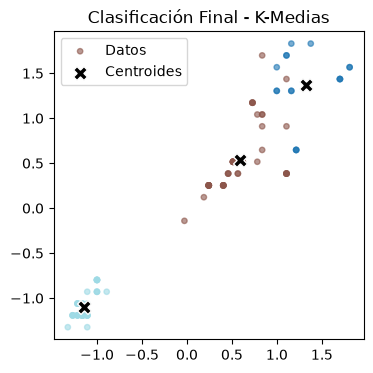

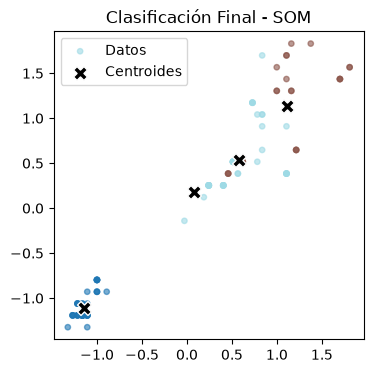

In [6]:
def cargar_datos(ruta_archivo):
    datos_x = []
    yd = []
    with open(ruta_archivo, 'r') as archivo:
        archivo_csv = csv.reader(archivo)
        for fila in archivo_csv:
            if not fila:
                continue
            entradas = [float(val) for val in fila[:4]]
            datos_x.append(entradas)

            salidas = [float(val) for val in fila[4:]]
            yd.append(salidas)
            
    return np.array(datos_x), np.array(yd)

def estandarizar(X):
    """Reemplazo manual de StandardScaler"""
    medias = np.mean(X, axis=0)
    desvios = np.std(X, axis=0)
    return (X - medias) / desvios

if __name__ == "__main__":  
    # CARGA DE DATOS
    X, Y_raw = cargar_datos('datos/iris81_trn.csv')
    
    # Argmax transforma [-1, -1, 1] en 2; [-1, 1, -1] en 1; [1, -1, -1] en 0
    y_true = np.argmax(Y_raw, axis=1)
    
    # El orden coincide con la transformación del np.argmax para tus datos
    nombres_clases = ["Virginica", "Versicolor", "Setosa"] 
    nombres_variables = ["Largo Sépalo", "Ancho Sépalo", "Largo Pétalo", "Ancho Pétalo"]

    # Estandarización obligatoria
    X_scaled = estandarizar(X)


    # ENTRENAMIENTO
    print("\nEntrenando K-Medias (K=3)...")
    kmeans = KMedias(X_scaled, k=3)
    kmeans.train()
    y_kmeans = kmeans.predict(X_scaled)

    print("Entrenando SOM (2x2)...")
    filas_som, cols_som = 2, 2
    som_iris = SOM(filas=filas_som, columnas=cols_som, dim_entrada=4, tasa_aprendizaje=0.5)
    som_iris.train(X_scaled, epocas_ordenamiento=500, epocas_transicion=300, epocas_ajuste=200)
    y_som_1d, bmus_2d = som_iris.obtener_bmus(X_scaled)


    # Seleccionamos variables: Largo Pétalo (2) y Ancho Pétalo (3)
    dim_x, dim_y = 2, 3 

    # Gráfico 1: K-Medias
    kmeans.graficar_clasificacion_2D(X_scaled, dim_x=dim_x, dim_y=dim_y)

    # Gráfico 2: Dispersión SOM
    som_iris.graficar_clasificacion_2D(X_scaled, dim_x=dim_x, dim_y=dim_y)   

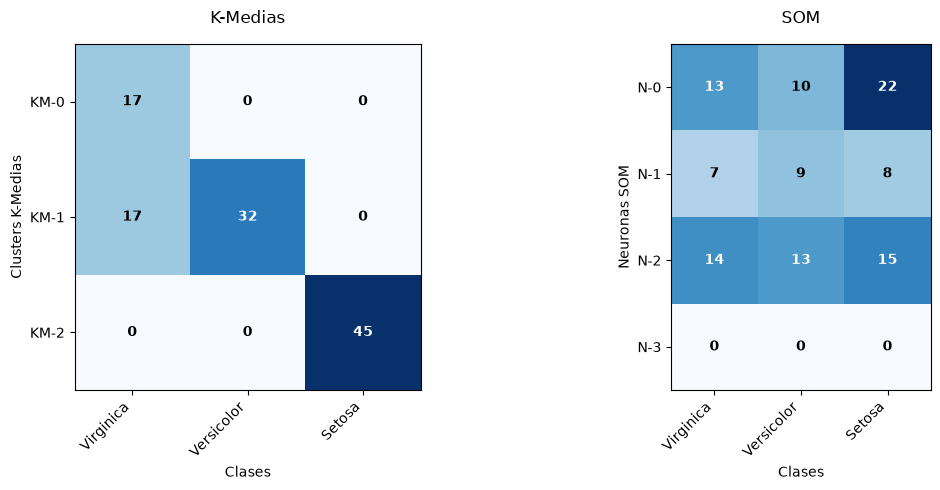

In [7]:
# FUNCIONES AUXILIARES PARA MATRICES
def matriz_contingencia_fija(labels_filas, labels_columnas, num_filas, num_columnas):
    """Crea la matriz forzando el tamaño exacto, para que aparezcan las neuronas vacías"""
    matriz = np.zeros((num_filas, num_columnas), dtype=int)
    
    for i in range(len(labels_filas)):
        f = labels_filas[i]
        c = labels_columnas[i]
        matriz[f, c] += 1
        
    return matriz

def graficar_matriz_contingencia(matriz, nombres_filas, nombres_columnas, titulo, ax):
    """Dibuja un mapa de calor para una matriz usando Matplotlib puro"""
    im = ax.imshow(matriz, cmap="Blues")
    
    ax.set_xticks(np.arange(len(nombres_columnas)))
    ax.set_yticks(np.arange(len(nombres_filas)))
    ax.set_xticklabels(nombres_columnas, rotation=45, ha="right")
    ax.set_yticklabels(nombres_filas)
    ax.set_title(titulo, fontsize=12, pad=15)
    
    umbral = matriz.max() / 2.0
    for i in range(len(nombres_filas)):
        for j in range(len(nombres_columnas)):
            color_texto = "white" if matriz[i, j] > umbral else "black"
            ax.text(j, i, str(matriz[i, j]), ha="center", va="center", color=color_texto, fontweight="bold")



# ==========================================
# GARFICO 
# Definimos las etiquetas y calculamos cuantas neuronas hay en total
nombres_km = ["KM-0", "KM-1", "KM-2"]
total_neuronas = filas_som * cols_som 
nombres_som = [f"N-{i}" for i in range(total_neuronas)] 

# Calculamos las matrices forzando el tamaño exacto
cm_kmeans_true = matriz_contingencia_fija(y_kmeans, y_true, len(nombres_km), len(nombres_clases))
cm_som_true = matriz_contingencia_fija(y_som_1d, y_true, total_neuronas, len(nombres_clases))

# Armamos la figura con 2 subgráficos horizontales (K-Medias y SOM contra los Reales)
fig, axs_mat = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico A: K-Medias vs Reales
graficar_matriz_contingencia(cm_kmeans_true, nombres_km, nombres_clases, "K-Medias", axs_mat[0])
axs_mat[0].set_ylabel("Clusters K-Medias")
axs_mat[0].set_xlabel("Clases")

# Gráfico B: SOM vs Reales
graficar_matriz_contingencia(cm_som_true, nombres_som, nombres_clases, "SOM", axs_mat[1])
axs_mat[1].set_ylabel("Neuronas SOM")
axs_mat[1].set_xlabel("Clases")

plt.tight_layout()
plt.show()

## EJERCICIO 3: K OPTIMO

K = 2 | Inercia = 162.44
K = 3 | Inercia = 103.71
K = 4 | Inercia = 78.93
K = 5 | Inercia = 80.90
K = 6 | Inercia = 72.59
K = 7 | Inercia = 67.49
K = 8 | Inercia = 50.57
K = 9 | Inercia = 38.47
K = 10 | Inercia = 43.05


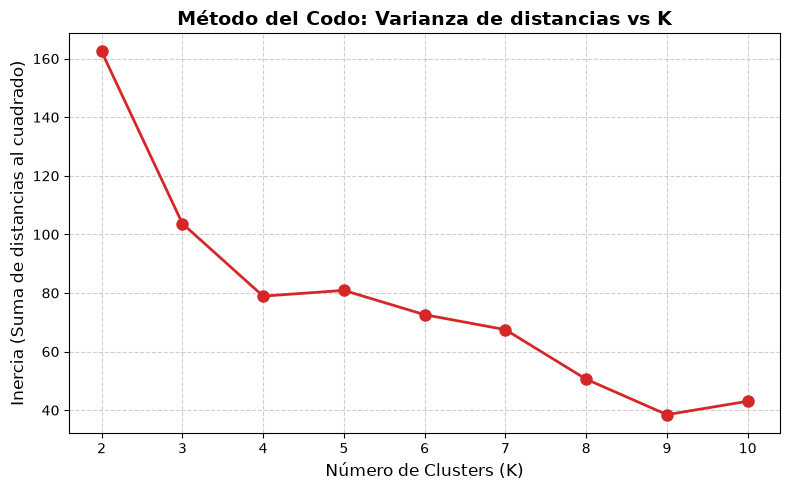

In [8]:
if __name__ == "__main__":
    k_valores = range(2, 11)
    inercias = []

    for k in k_valores:
        # Entrenamos el modelo para cada K
        kmeans_test = KMedias(X_scaled, k=k, max_iter=100)
        kmeans_test.train()
        
        # Guardamos la inercia (Suma de distancias al cuadrado intra-cluster)
        inercias.append(kmeans_test.inercia)
        print(f"K = {k} | Inercia = {kmeans_test.inercia:.2f}")

    # GRAFICO: METODO DEL CODO
    plt.figure(figsize=(8, 5))
    
    # Dibujamos la línea con los puntos
    plt.plot(k_valores, inercias, marker='o', linestyle='-', color='tab:red', linewidth=2, markersize=8)
    
    plt.title("Método del Codo: Varianza de distancias vs K", fontsize=14, fontweight='bold')
    plt.xlabel("Número de Clusters (K)", fontsize=12)
    plt.ylabel("Inercia (Suma de distancias al cuadrado)", fontsize=12)
    
    # Aseguramos que el eje X muestre todos los números enteros
    plt.xticks(k_valores)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()